In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ultralytics import YOLO


New https://pypi.org/project/ultralytics/8.4.163 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.150  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5090, 32607MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset\kfold\fold_0, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=mod

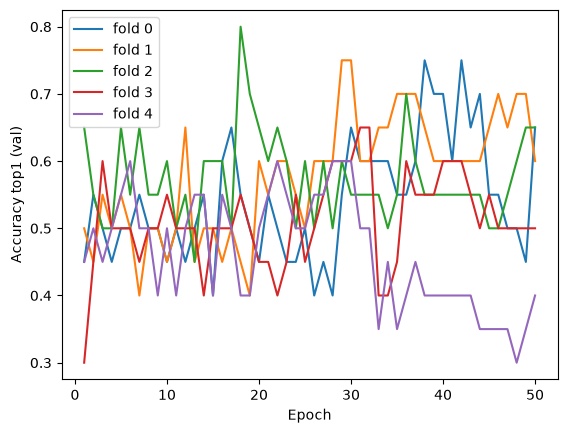

Scores par fold : [       0.75        0.75         0.8        0.65         0.6]
Accuracy moyenne : 0.7100000023841858
Écart-type : 0.0821583832630345


In [ ]:
def train_kfold(n: int, dataset: str):
    dataset = Path(dataset)
    scores = []
    histories = []
    for i in range(n):
        
        model = YOLO("models/yolo11x-cls.pt")
        
        fold_path = dataset / f"fold_{i}"
        model.train(
            data=fold_path,
            project="train",
            name="eye_side_classification", 
            epochs=50,
            imgsz=512,
            batch=8,
            device=0, # GPU
            optimizer='SGD'
        )
        
        
        path = "train" / "result" / f"fold_{i}"
        df = pd.read_csv(path / "results.csv")
        df.columns = df.columns.str.strip()
        histories.append(df)
        
        metrics = model.val()
        
        scores.append(metrics.top1)
        
    return scores, histories
        

scores, histories = train_kfold(5, "dataset/kfold")
scores = np.asarray(scores)

for i, df in enumerate(histories):
    plt.plot(df["epoch"], df["metrics/accuracy_top1"], label=f"fold {i}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy top1 (val)")
plt.legend()
plt.show()

print("Scores par fold :", scores)
print("Accuracy moyenne :", scores.mean())
print("Écart-type :", scores.std(ddof=1))
        